In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Optional (we’ll use later)
# pip install xgboost
from xgboost import XGBRegressor

In [2]:
# Load carrot rolling-window dataset
file_path = "../datasets/carrot_complete_growth_dataset.xlsx"
df = pd.read_excel(file_path)

df.head()

,Date,Carrot_Avg_Price,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d
0,2020-06-15,100.00 - 130.00,100,130,500,4160,180,300,1000,29.560746,19.703947,15.954167,23.262500,14.764912,6.522357,81.799781,67.789693,232.072149,32.972588,20.062939
1,2020-06-16,100.00 - 120.00,100,120,500,4160,180,300,1000,29.564693,19.762061,15.990789,23.277193,14.732456,6.523658,81.956360,67.951096,231.635307,33.113816,20.024781
2,2020-06-17,100.00 - 130.00,100,130,500,4160,180,300,1000,29.559430,19.836842,16.014912,23.295175,14.854386,6.538441,82.179825,68.410307,230.398026,33.246711,19.917982
3,2020-06-18,90.00 - 120.00,90,120,500,4160,180,300,1000,29.558553,19.868202,16.049781,23.313596,15.001316,6.538781,82.225000,68.973465,229.512061,33.292982,19.842325
4,2020-06-19,70.00 - 100.00,70,100,500,4160,180,300,1000,29.588816,19.871711,16.069518,23.343202,15.048465,6.503066,82.108333,69.005921,229.419956,33.393421,19.834868


In [3]:
df.shape

(1334, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               1334 non-null   datetime64[ns]
 1   Carrot_Avg_Price                   1334 non-null   object        
 2   Carrot_Min_Price                   1334 non-null   int64         
 3   Carrot_Max_Price                   1334 non-null   int64         
 4   Labour Cost                        1334 non-null   int64         
 5   Transportation Cost                1334 non-null   int64         
 6   Fertilizer (Urea)                  1334 non-null   int64         
 7   Fertilizer(MOP)                    1334 non-null   int64         
 8   Plantation Crop                    1334 non-null   int64         
 9   Average of tempmax_avg_75d         1334 non-null   float64       
 10  Average of dew_avg_75d             1

In [5]:
df.describe()

,Date,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d
count,1334,1334.000000,1334.000000,1334.000000,1334.000000,1334.0,1334.0,1334.0,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000,1334.000000
mean,2022-12-05 23:21:08.365817088,204.224138,252.616192,1031.746627,11440.029985,180.0,300.0,1000.0,28.188871,19.335223,16.258468,22.401935,14.514852,7.215563,84.178281,73.157559,212.330852,33.812761,18.334645
min,2020-06-15 00:00:00,40.000000,35.000000,500.000000,4160.000000,180.0,300.0,1000.0,25.749561,17.825658,13.845175,20.594298,9.622368,1.515282,75.804825,52.433947,161.640921,26.288158,13.935000
25%,2021-12-20 06:00:00,100.000000,140.000000,800.000000,7040.000000,180.0,300.0,1000.0,27.294221,18.795559,15.366338,21.696612,11.854112,5.024067,81.757346,69.318092,198.599803,29.193092,17.147171
50%,2022-12-30 12:00:00,165.000000,205.000000,950.000000,11320.000000,180.0,300.0,1000.0,28.413268,19.192873,16.385263,22.528147,13.272007,6.365489,84.366228,75.450395,217.794408,32.950504,18.802632
75%,2024-01-08 18:00:00,250.000000,300.000000,1300.000000,12240.000000,180.0,300.0,1000.0,29.037730,19.921985,16.820450,23.037829,17.354879,8.652572,86.211184,78.354002,226.650493,38.366502,19.571217
max,2024-12-31 00:00:00,1700.000000,2000.000000,1300.000000,16600.000000,180.0,300.0,1000.0,30.151842,21.238947,20.006579,24.644211,22.322632,18.429480,92.056053,83.658947,261.596842,44.517895,22.615000
std,NaN,155.798338,193.713599,252.620223,3874.787258,0.0,0.0,0.0,1.066408,0.770447,1.335640,0.967984,3.335480,3.552340,3.245506,6.926954,21.132662,4.932633,1.831417


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


In [7]:
# Lag features for Min Price
df["min_lag_1"] = df["Carrot_Min_Price"].shift(1)
df["min_lag_3"] = df["Carrot_Min_Price"].shift(3)
df["min_lag_7"] = df["Carrot_Min_Price"].shift(7)

# Lag features for Max Price
df["max_lag_1"] = df["Carrot_Max_Price"].shift(1)
df["max_lag_3"] = df["Carrot_Max_Price"].shift(3)
df["max_lag_7"] = df["Carrot_Max_Price"].shift(7)


In [8]:
feature_cols = [
    "Labour Cost",
    "Transportation Cost",
    "Fertilizer (Urea)",
    "Fertilizer(MOP)",
    "min_lag_1", "min_lag_3", "min_lag_7",
    "max_lag_1", "max_lag_3", "max_lag_7"
]

X = df[feature_cols]

In [9]:
y_min = df["Carrot_Min_Price"]
y_max = df["Carrot_Max_Price"]

In [10]:
# Combine X and y to drop NaNs safely
data = pd.concat([X, y_min, y_max], axis=1)

# Drop rows with any missing values
data = data.dropna().reset_index(drop=True)

# Re-split X and y
X = data[feature_cols]
y_min = data["Carrot_Min_Price"]
y_max = data["Carrot_Max_Price"]

In [11]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_min_train, y_min_test = y_min.iloc[:split_index], y_min.iloc[split_index:]
y_max_train, y_max_test = y_max.iloc[:split_index], y_max.iloc[split_index:]


In [12]:
# Linear Regression model for Min Price
lr_min = LinearRegression()
lr_min.fit(X_train, y_min_train)

# Predictions
y_min_pred = lr_min.predict(X_test)

In [13]:
mae_min = mean_absolute_error(y_min_test, y_min_pred)
rmse_min = np.sqrt(mean_squared_error(y_min_test, y_min_pred))
r2_min = r2_score(y_min_test, y_min_pred)

print("Linear Regression - Min Price")
print(f"MAE  : {mae_min:.2f}")
print(f"RMSE : {rmse_min:.2f}")
print(f"R²   : {r2_min:.3f}")

Linear Regression - Min Price
MAE  : 22.18
RMSE : 31.28
R²   : 0.881


In [14]:
# Linear Regression model for Max Price
lr_max = LinearRegression()
lr_max.fit(X_train, y_max_train)

# Predictions
y_max_pred = lr_max.predict(X_test)

In [15]:
mae_max = mean_absolute_error(y_max_test, y_max_pred)
rmse_max = np.sqrt(mean_squared_error(y_max_test, y_max_pred))
r2_max = r2_score(y_max_test, y_max_pred)

print("Linear Regression - Max Price")
print(f"MAE  : {mae_max:.2f}")
print(f"RMSE : {rmse_max:.2f}")
print(f"R²   : {r2_max:.3f}")

Linear Regression - Max Price
MAE  : 22.08
RMSE : 32.38
R²   : 0.899


In [16]:
# Prediction horizon
forecast_dates = pd.date_range(
    start="2025-02-01",
    end="2025-03-31",
    freq="D"
)

forecast_dates

DatetimeIndex(['2025-02-01', '2025-02-02', '2025-02-03', '2025-02-04',
               '2025-02-05', '2025-02-06', '2025-02-07', '2025-02-08',
               '2025-02-09', '2025-02-10', '2025-02-11', '2025-02-12',
               '2025-02-13', '2025-02-14', '2025-02-15', '2025-02-16',
               '2025-02-17', '2025-02-18', '2025-02-19', '2025-02-20',
               '2025-02-21', '2025-02-22', '2025-02-23', '2025-02-24',
               '2025-02-25', '2025-02-26', '2025-02-27', '2025-02-28',
               '2025-03-01', '2025-03-02', '2025-03-03', '2025-03-04',
               '2025-03-05', '2025-03-06', '2025-03-07', '2025-03-08',
               '2025-03-09', '2025-03-10', '2025-03-11', '2025-03-12',
               '2025-03-13', '2025-03-14', '2025-03-15', '2025-03-16',
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24',
               '2025-03-25', '2025-03-26', '2025-03-27', '2025-03-28',
      

In [17]:
last_row = df.iloc[-1].copy()

last_row

Date                                 2024-12-31 00:00:00
Carrot_Avg_Price                               180 - 250
Carrot_Min_Price                                     180
Carrot_Max_Price                                     250
Labour Cost                                         1300
Transportation Cost                                11320
Fertilizer (Urea)                                    180
Fertilizer(MOP)                                      300
Plantation Crop                                     1000
Average of tempmax_avg_75d                     27.248158
Average of dew_avg_75d                         20.312105
Average of tempmin_avg_75d                     17.974474
Average of temp_avg_75d                        22.653684
Average of windspeed_avg_75d                   10.412632
Average of precip_avg_75d                       9.666713
Average of humidity_avg_75d                    87.669474
Average of cloudcover_avg_75d                  74.283421
Average of solarradiation_avg_7

In [18]:
# Initial lag values
min_lag_1 = last_row["Carrot_Min_Price"]
min_lag_3 = df.iloc[-3]["Carrot_Min_Price"]
min_lag_7 = df.iloc[-7]["Carrot_Min_Price"]

max_lag_1 = last_row["Carrot_Max_Price"]
max_lag_3 = df.iloc[-3]["Carrot_Max_Price"]
max_lag_7 = df.iloc[-7]["Carrot_Max_Price"]

In [19]:
predictions = []

for date in forecast_dates:
    X_pred = pd.DataFrame([{
        "Labour Cost": last_row["Labour Cost"],
        "Transportation Cost": last_row["Transportation Cost"],
        "Fertilizer (Urea)": last_row["Fertilizer (Urea)"],
        "Fertilizer(MOP)": last_row["Fertilizer(MOP)"],
        "min_lag_1": min_lag_1,
        "min_lag_3": min_lag_3,
        "min_lag_7": min_lag_7,
        "max_lag_1": max_lag_1,
        "max_lag_3": max_lag_3,
        "max_lag_7": max_lag_7
    }])

    # Predict min & max prices
    pred_min = lr_min.predict(X_pred)[0]
    pred_max = lr_max.predict(X_pred)[0]

    predictions.append({
        "Date": date,
        "Predicted_Min_Price": round(pred_min, 2),
        "Predicted_Max_Price": round(pred_max, 2),
        "Predicted_Avg_Price": round((pred_min + pred_max) / 2, 2)
    })

    # Update lags (recursive step)
    min_lag_7 = min_lag_3
    min_lag_3 = min_lag_1
    min_lag_1 = pred_min

    max_lag_7 = max_lag_3
    max_lag_3 = max_lag_1
    max_lag_1 = pred_max


In [20]:
forecast_df = pd.DataFrame(predictions)
forecast_df


,Date,Predicted_Min_Price,Predicted_Max_Price,Predicted_Avg_Price
0,2025-02-01,166.41,221.55,193.98
1,2025-02-02,181.50,237.24,209.37
2,2025-02-03,184.82,232.36,208.59
3,2025-02-04,185.36,231.10,208.23
4,2025-02-05,188.14,231.73,209.94
5,2025-02-06,191.82,235.00,213.41
6,2025-02-07,195.29,238.18,216.73
7,2025-02-08,198.78,242.03,220.41
8,2025-02-09,202.33,246.14,224.23
9,2025-02-10,205.86,250.47,228.17


In [21]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


In [22]:
df["Avg_Price"] = (df["Carrot_Min_Price"] + df["Carrot_Max_Price"]) / 2


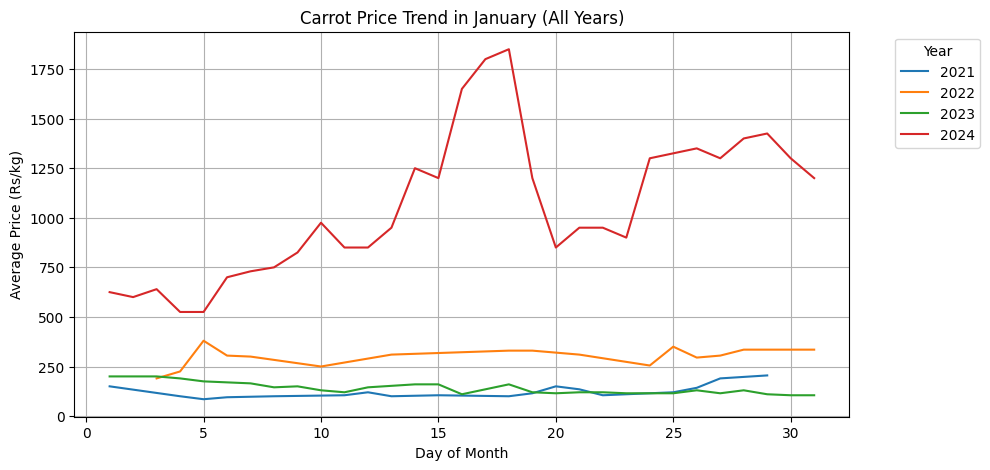

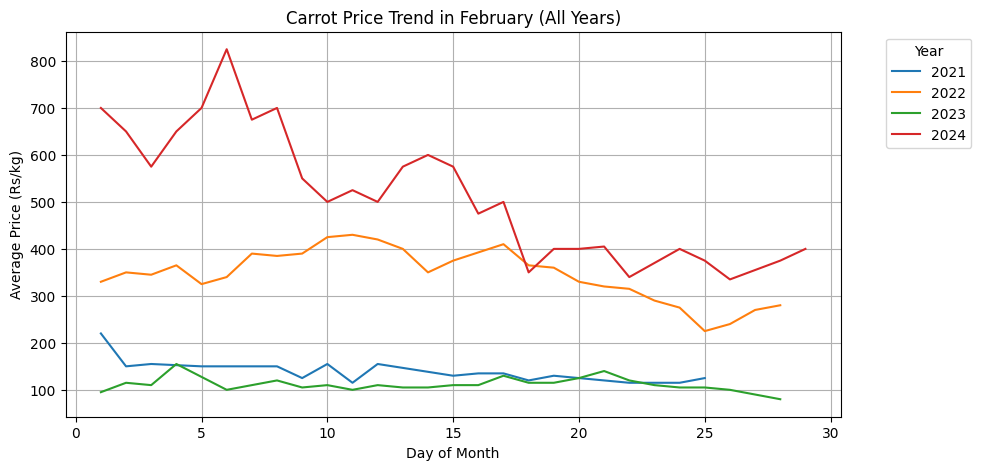

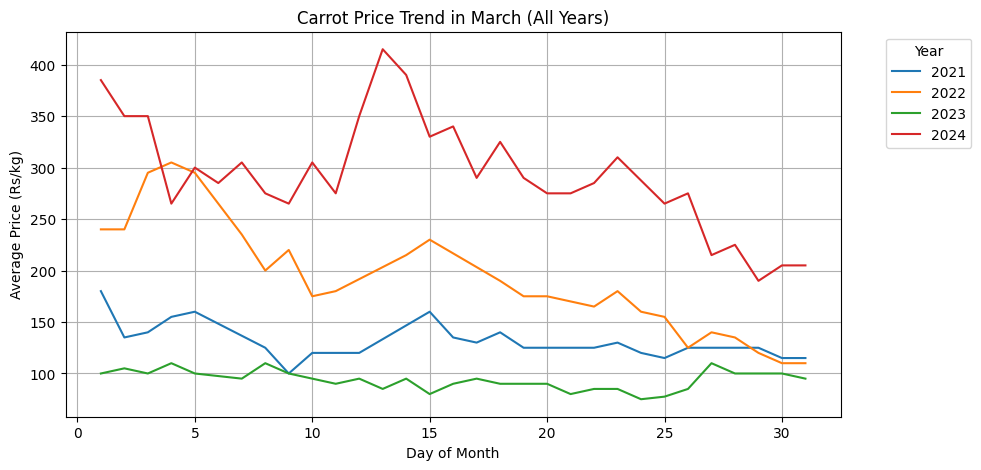

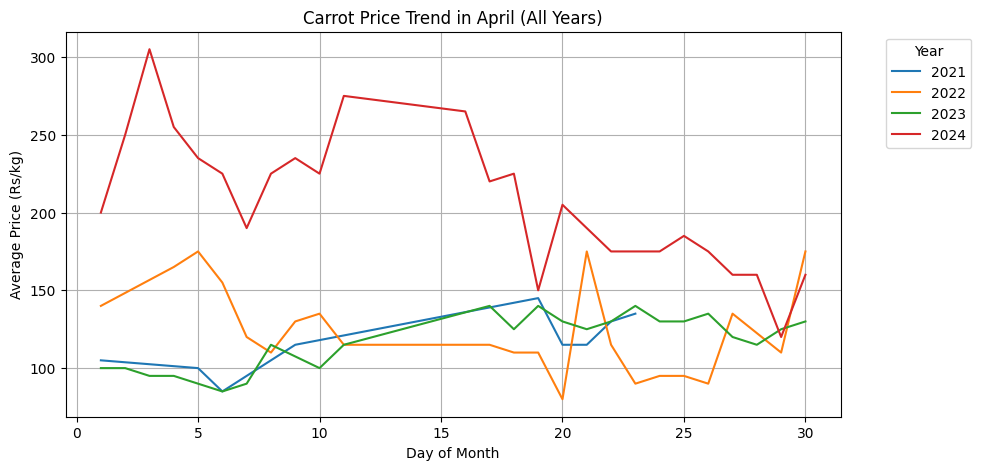

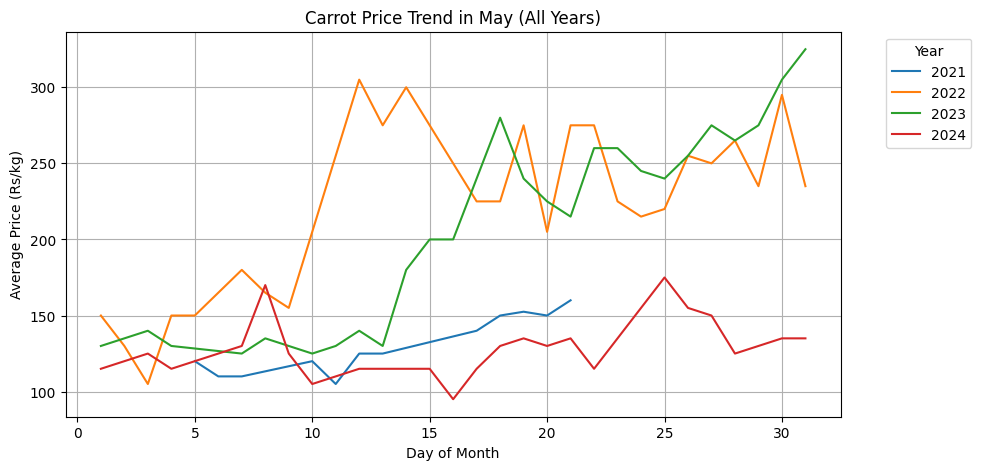

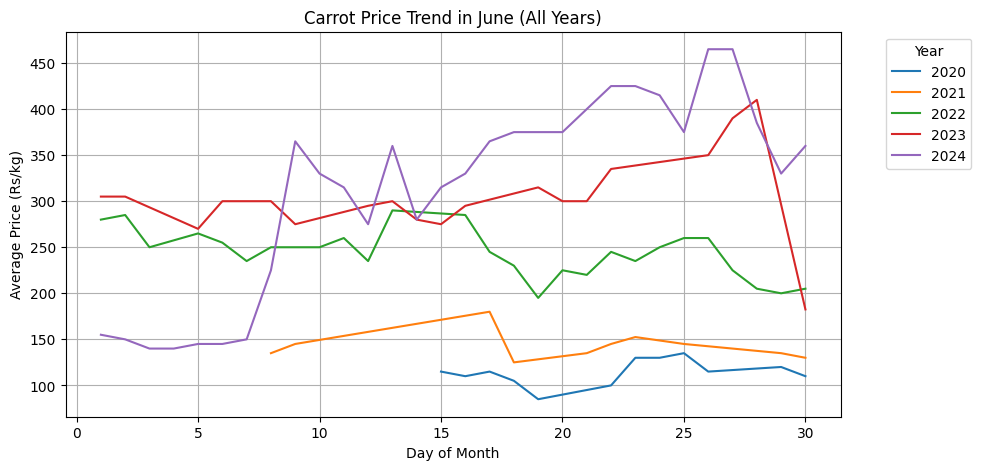

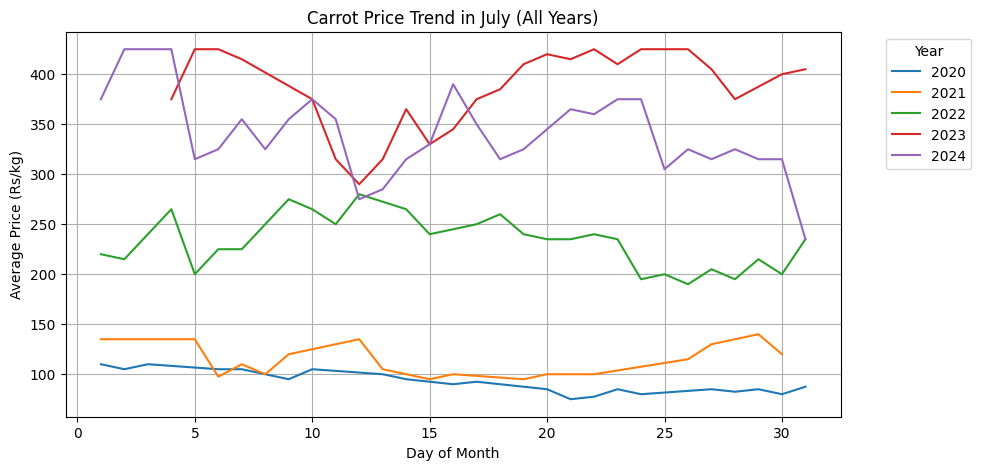

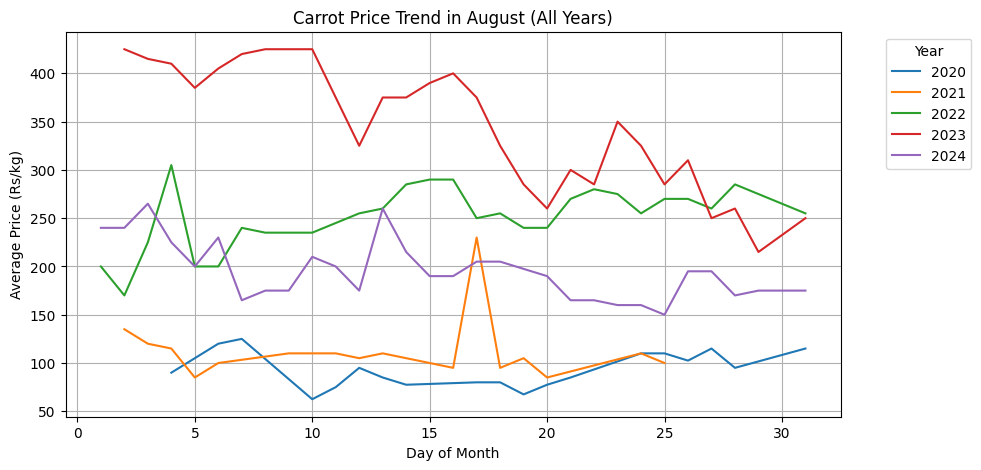

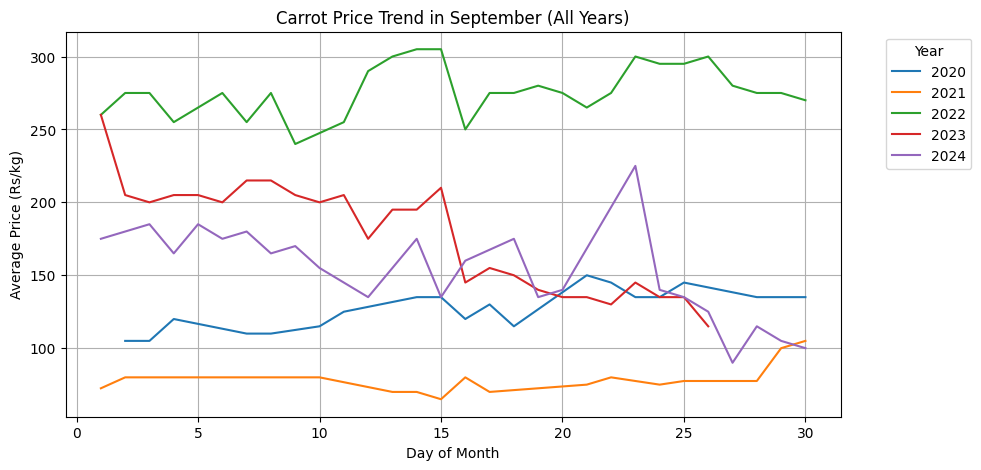

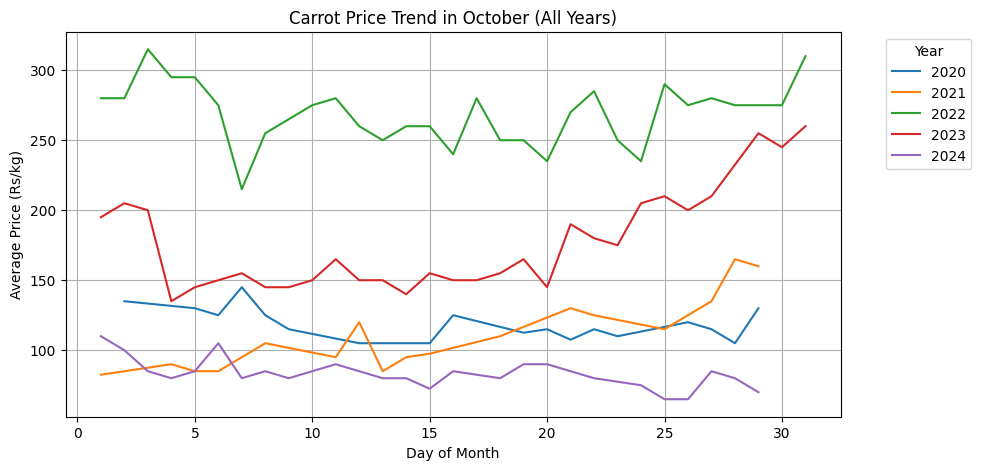

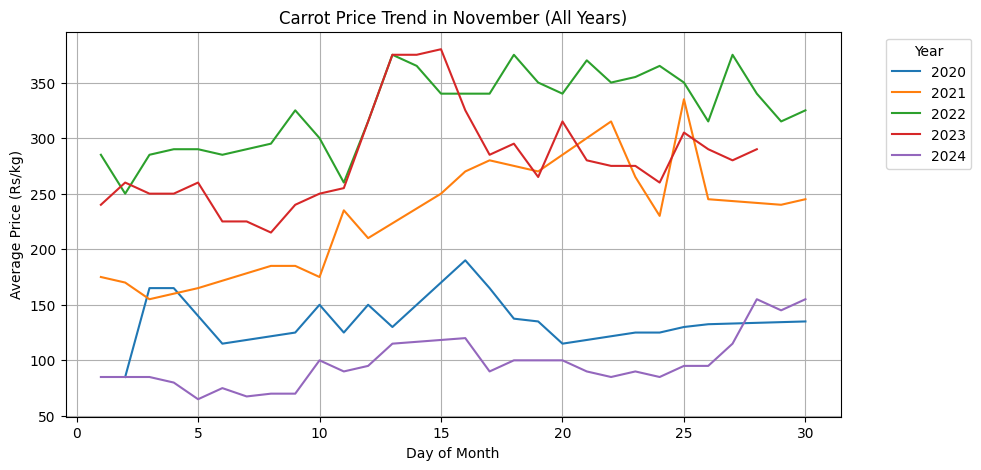

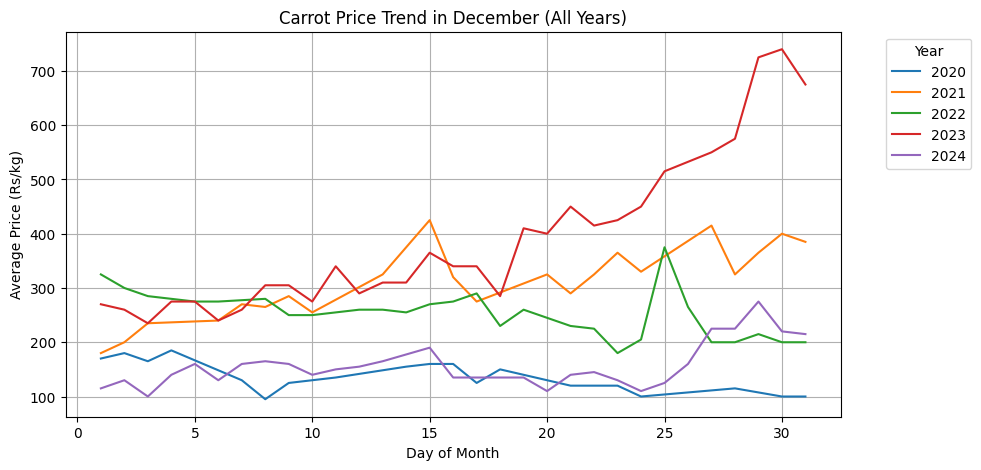

In [23]:
import matplotlib.pyplot as plt

month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

for month in range(1, 13):
    
    plt.figure(figsize=(10, 5))
    
    month_df = df[df["Month"] == month]
    
    for year in sorted(month_df["Year"].unique()):
        year_df = month_df[month_df["Year"] == year]
        plt.plot(
            year_df["Day"],
            year_df["Avg_Price"],
            label=str(year)
        )
    
    plt.title(f"Carrot Price Trend in {month_names[month]} (All Years)")
    plt.xlabel("Day of Month")
    plt.ylabel("Average Price (Rs/kg)")
    plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    
    plt.show()
